## Alzheimers Dataset Exploratory Data Analysis
This notebook is intended for learning purposes. Some codes might be redundant which are intentional. 

In [24]:
# Import required library 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [8]:
df = pd.read_csv("/Users/sorenbasnet/Documents/Github/PYTHON/STAT_443/data/alzheimers_disease_data.csv")

# Basic overview of the dataset 

print(df.shape)
print(df.dtypes)

(2149, 35)

PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems        

In [30]:
# Not included in the real notebook 
df.columns # used to see all the columns 

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [9]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [10]:
# Automated summary 

summary = df.describe(include='all').T
summary['missing_pct'] = df.isna().mean()
summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing_pct
PatientID,2149.0,NaN,NaN,NaN,5825.0,620.507185,4751.0,5288.0,5825.0,6362.0,6899.0,0.0
Age,2149.0,NaN,NaN,NaN,74.908795,8.990221,60.0,67.0,75.0,83.0,90.0,0.0
Gender,2149.0,NaN,NaN,NaN,0.506282,0.500077,0.0,0.0,1.0,1.0,1.0,0.0
Ethnicity,2149.0,NaN,NaN,NaN,0.697534,0.996128,0.0,0.0,0.0,1.0,3.0,0.0
EducationLevel,2149.0,NaN,NaN,NaN,1.286645,0.904527,0.0,1.0,1.0,2.0,3.0,0.0
BMI,2149.0,NaN,NaN,NaN,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767,0.0
Smoking,2149.0,NaN,NaN,NaN,0.288506,0.453173,0.0,0.0,0.0,1.0,1.0,0.0
AlcoholConsumption,2149.0,NaN,NaN,NaN,10.039442,5.75791,0.002003,5.13981,9.934412,15.157931,19.989293,0.0
PhysicalActivity,2149.0,NaN,NaN,NaN,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429,0.0
DietQuality,2149.0,NaN,NaN,NaN,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346,0.0


In [18]:
# Missing values now 

missing = df.isna().sum()
type(missing) #pandas.core.series.Series
print(missing[missing > 0])


Series([], dtype: int64)


In [19]:
# Duplicated rows 

duplicated = df.duplicated().sum()
print(f"Duplicate rows : {duplicated}")


Duplicate rows : 0


In [22]:
# Outliers for numeric columns 

for col in df.select_dtypes(include='number').columns: 
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"{col} outliers: {len(outliers)}")



PatientID outliers: 0
Age outliers: 0
Gender outliers: 0
Ethnicity outliers: 211
EducationLevel outliers: 0
BMI outliers: 0
Smoking outliers: 0
AlcoholConsumption outliers: 0
PhysicalActivity outliers: 0
DietQuality outliers: 0
SleepQuality outliers: 0
FamilyHistoryAlzheimers outliers: 0
CardiovascularDisease outliers: 310
Diabetes outliers: 324
Depression outliers: 431
HeadInjury outliers: 199
Hypertension outliers: 320
SystolicBP outliers: 0
DiastolicBP outliers: 0
CholesterolTotal outliers: 0
CholesterolLDL outliers: 0
CholesterolHDL outliers: 0
CholesterolTriglycerides outliers: 0
MMSE outliers: 0
FunctionalAssessment outliers: 0
MemoryComplaints outliers: 447
BehavioralProblems outliers: 337
ADL outliers: 0
Confusion outliers: 441
Disorientation outliers: 340
PersonalityChanges outliers: 324
DifficultyCompletingTasks outliers: 341
Forgetfulness outliers: 0
Diagnosis outliers: 0


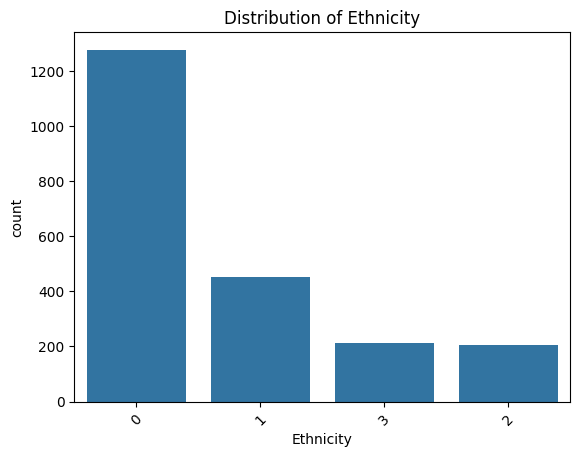

In [33]:
# Visualization of Ethnicity 

sns.countplot(x='Ethnicity', data=df, order=df['Ethnicity'].value_counts().index)
plt.xticks(rotation=45) # for the label to rotate if they are too long 
                        # change it back to 90 or sth 
plt.title('Distribution of Ethnicity')
plt.show()


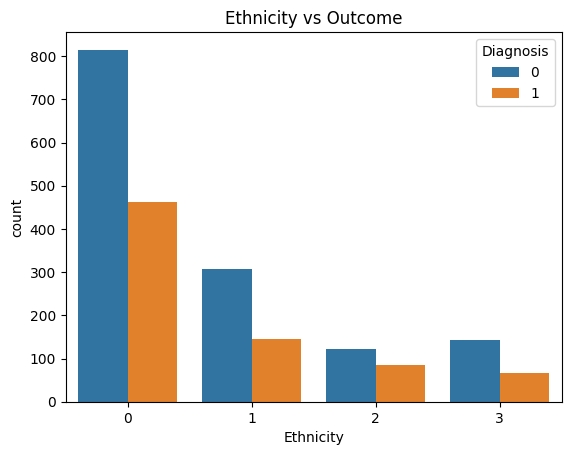

In [37]:
# This can be now used to see how ethnicities relates to the outcome 

sns.countplot(x='Ethnicity', hue='Diagnosis', data=df)
plt.xticks()
plt.title('Ethnicity vs Outcome')
plt.show()



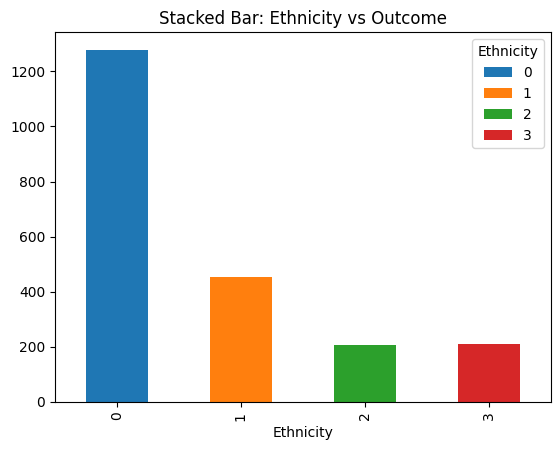

In [39]:
eth_outcome = pd.crosstab(df['Ethnicity'], df['Ethnicity'])
eth_outcome.plot(kind='bar', stacked=True)
plt.title('Stacked Bar: Ethnicity vs Outcome')
plt.show()